<a href="https://colab.research.google.com/github/ssarinbe24-sys/AI_for_Cybersecurity-/blob/main/Malware_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Malware Detection Using Supervised Learning

In this notebook, we'll work on detecting malware by training a model on a dataset. The  understand the concepts, code, and analysis involved in malware detection.

Malware detection involves identifying malicious software that can compromise systems and networks. This project uses machine learning to classify files as either malware or benign. By analyzing patterns in the data, machine learning models can learn to detect malware effectively.

##Importing Libraries

This section imports the necessary libraries for data analysis, visualization, and model training. Learners should make sure they have these libraries installed, or they can use !pip install library_name to install any missing libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

##Loading and Inspecting the Dataset
Load the malware dataset and inspect its initial structure. Use pd.read_csv() (or the appropriate method) to load the dataset. Display the first few rows with head() to understand the data layout and types.

In this step, we load our malware dataset and take a quick look at the first few rows to understand its structure and the type of features it contains.

Dataset, labeled 1 (goodware) and -1 (malware).

In [2]:
data = pd.read_csv('DynamicMalwareMatrix2.csv')

In [3]:
data.head()

,labels,00,0000,0000000,000000000046,00021401,00c04fc295ee,01,0156250,02,...,windowsruntime,winevt,wmiprvse,working,wow6432node,write,writefile,xaml,xls,zip
0,1,11,0,5,0,0,0,1,6,0,...,0,0,0,36,0,0,0,0,0,0
1,1,0,0,1,0,0,0,0,0,0,...,0,0,0,19,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,3,0,...,0,0,0,8,0,0,0,0,0,0
3,1,52,0,2,0,0,0,2,0,6,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data.shape

(34371, 501)

In [5]:
## Checking all columns name

In [6]:
for i in data.columns:
    print(i, end=', ')

labels, 00, 0000, 0000000, 000000000046, 00021401, 00c04fc295ee, 01, 0156250, 02, 03, 04, 05, 06, 07, 08, 08002b30309d, 09, 096, 0_x64__8wekyb3d8bbwe, 0e5aae11, 0x0, 0x1, 10, 1000, 1004, 101, 1012, 1036, 1069, 11, 1148, 11cf, 11d0, 11d1, 12, 128, 13, 14, 144, 1440, 1496, 15, 16, 17, 17763, 17763_neutral_neutral_cw5n1h2txyewy, 18, 1836, 189871a37d4dc8849f801e42ea1b8d09167cba5fd9d0b2dadafd002ff99e33ee, 19, 192, 1940, 20, 2018, 2019, 2022, 2040, 20d04fe0, 21, 2103, 22, 2269080069, 23, 2372, 24, 25, 26, 2684, 27, 28, 2828, 288, 29, 30, 3020, 30319_32, 3036, 3052, 3064, 307355e4b60e, 3084, 31, 3156, 3168, 319b4a97ea03, 32, 320, 3240, 328, 33, 3364, 34, 3461203602, 35, 36, 37, 3780, 38, 384, 3876, 3884, 39, 3908, 3aea, 40, 4048, 4096304019, 41, 42, 424c, 4284, 43, 44, 440, 444553540000, 45, 46, 467a, 47, 4700, 48, 4804, 4888, 49, 4951, 4b01, 4c5b, 4dbd, 50, 51, 5108, 511, 5180, 52, 53, 536, 54, 5420, 5476, 55, 56, 57, 576, 58, 588, 59, 608, 68, 696, 707907bf, 71eb, 720, 73, 756, 768, 78, 7fe

In [7]:
## way to check how malware record in dataset

In [8]:
len(data[data['labels'] == -1])

16923

##Train-Test Split
Splitting the data allows for an unbiased evaluation of the model’s performance on unseen data, helping to avoid overfitting.

Separate the data into training and test sets to evaluate model performance effectively. Instructions: Use train_test_split() from sklearn.model_selection to divide the data, typically with 70-80% for training and the remainder for testing.

In [9]:
# Storing features and labels in X and y respectively.
X = data.iloc[:,1:501].values
y = data.iloc[:,0].values

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 100, test_size= 0.3)

In [11]:
scores = []

##Modeling with Decision Trees

Begin with simple models like Decision Trees, then explore advanced models (e.g., Random Forests, Gradient Boosting). Fit each model to the training data and evaluate using the test set.

In [12]:
Treemodel = DecisionTreeClassifier(random_state = 42)

In [13]:
tree = Treemodel.fit(X_train, y_train)

In [14]:
# predicting Values
y_pred = tree.predict(X_test)
test_comparison = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
test_comparison.head(10)

,y_test,y_pred
0,-1,-1
1,-1,-1
2,1,1
3,1,1
4,-1,-1
5,1,1
6,-1,-1
7,1,1
8,1,1
9,-1,-1


##Model Evaluation
Evaluation metrics help determine the model’s accuracy and ability to correctly identify malware. Precision and recall are particularly important, as false negatives (missed malware) can be critical.

Use metrics like accuracy, precision, recall, and F1-score to evaluate the model’s effectiveness. Generate a confusion matrix to analyze true positives, false positives, etc.

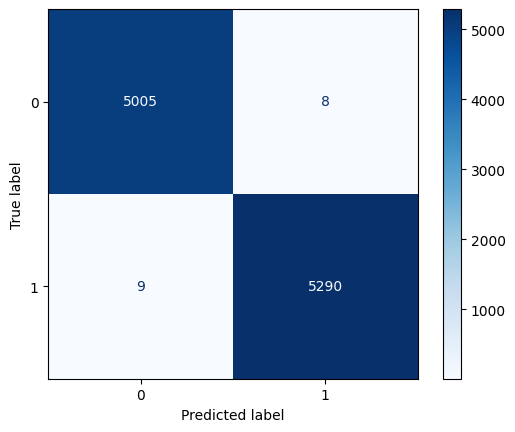

In [15]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
cm_display.plot(cmap='Blues')

In [16]:
print('Classification Report', classification_report(y_test, y_pred))

Classification Report               precision    recall  f1-score   support

          -1       1.00      1.00      1.00      5013
           1       1.00      1.00      1.00      5299

    accuracy                           1.00     10312
   macro avg       1.00      1.00      1.00     10312
weighted avg       1.00      1.00      1.00     10312



<Axes: >

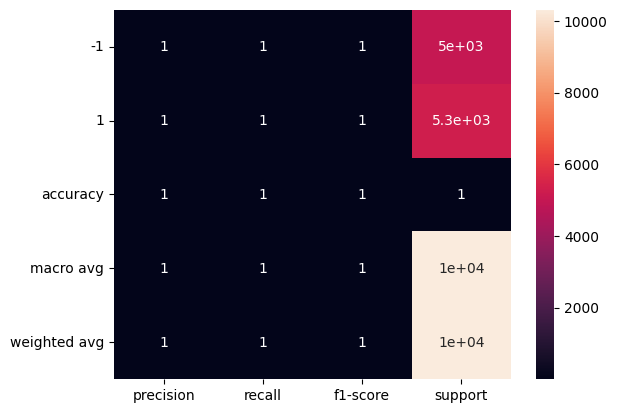

In [17]:
clf_report = classification_report(y_test, y_pred, output_dict = True)
sns.heatmap(pd.DataFrame(clf_report).T, annot=True)

In [18]:
print('Score', tree.score(X_test, y_test))
scores.append(tree.score(X_test, y_test))

Score 0.9983514352211016


##Logistic Regression Model

Scaling is essential for logistic regression, as it relies on distance metrics. Logistic regression serves as a baseline for comparison with more complex models. This code applied logistic regression, a linear model, for binary classification.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Standard Scaling
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [20]:
#Importing model
logmodel = LogisticRegression(max_iter=500)

In [21]:
log = logmodel.fit(X_train, y_train)

In [22]:
# performning prediction on test set
y_pred = log.predict(X_test)
test_comparison = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
test_comparison.head(10)

,y_test,y_pred
0,-1,-1
1,-1,-1
2,1,1
3,1,1
4,-1,-1
5,1,1
6,-1,-1
7,1,1
8,1,1
9,-1,-1


In [23]:
cm = confusion_matrix(y_test,y_pred)
print('Confusion Matrix','\n', cm)

Confusion Matrix 
 [[5013    0]
 [   1 5298]]


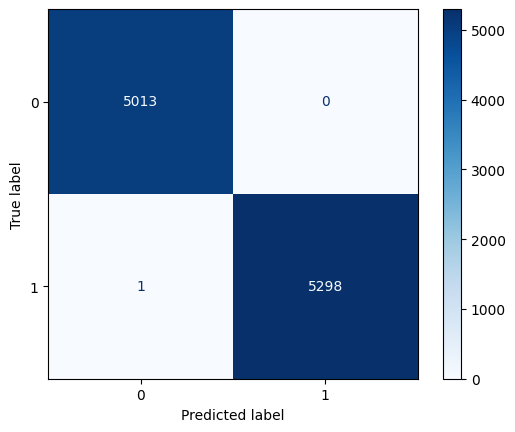

In [24]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
cm_display.plot(cmap='Blues')

In [25]:
print('Classification Report', classification_report(y_test, y_pred))

Classification Report               precision    recall  f1-score   support

          -1       1.00      1.00      1.00      5013
           1       1.00      1.00      1.00      5299

    accuracy                           1.00     10312
   macro avg       1.00      1.00      1.00     10312
weighted avg       1.00      1.00      1.00     10312



<Axes: >

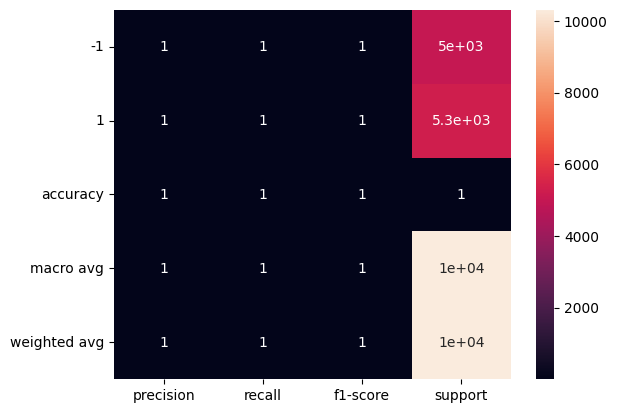

In [26]:
clf_report = classification_report(y_test, y_pred, output_dict = True)
sns.heatmap(pd.DataFrame(clf_report).T, annot=True)

In [27]:
print('Score', log.score(X_test, y_test))
scores.append(log.score(X_test, y_test))

Score 0.9999030256012412


##Support Vector Machine (SVM)

Support Vector Machines are effective for high-dimensional spaces and can capture complex decision boundaries. The code trains a Support Vector Classifier (SVC) model.

In [28]:
svcmodel = SVC( kernel = 'rbf',)

In [29]:
svc = svcmodel.fit(X_train, y_train)

In [30]:
# predicting values
y_pred = log.predict(X_test)
test_comparison = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
test_comparison.head(10)

,y_test,y_pred
0,-1,-1
1,-1,-1
2,1,1
3,1,1
4,-1,-1
5,1,1
6,-1,-1
7,1,1
8,1,1
9,-1,-1


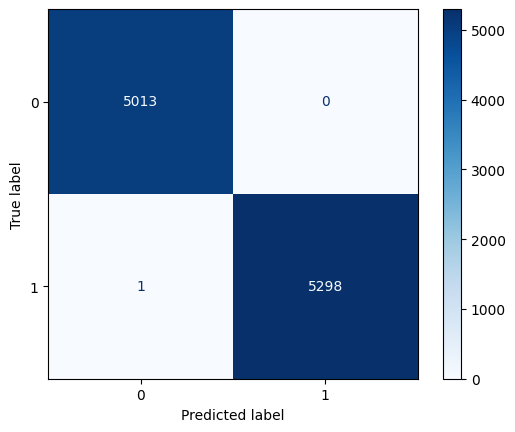

In [31]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
cm_display.plot(cmap='Blues')

In [32]:
print('Classification Report', classification_report(y_test, y_pred))

Classification Report               precision    recall  f1-score   support

          -1       1.00      1.00      1.00      5013
           1       1.00      1.00      1.00      5299

    accuracy                           1.00     10312
   macro avg       1.00      1.00      1.00     10312
weighted avg       1.00      1.00      1.00     10312



<Axes: >

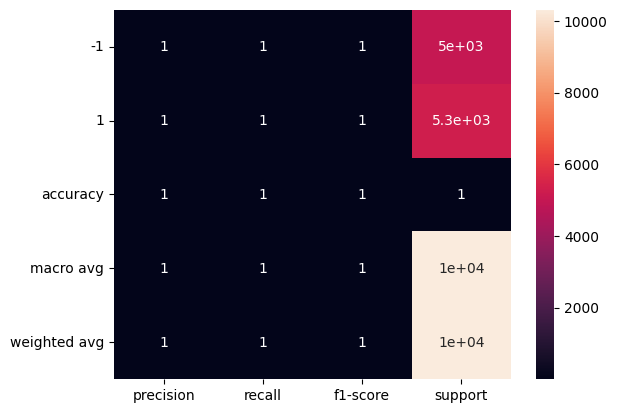

In [33]:
clf_report = classification_report(y_test, y_pred, output_dict = True)
sns.heatmap(pd.DataFrame(clf_report).T, annot=True)

In [34]:
print('Score', svc.score(X_test, y_test))
scores.append(svc.score(X_test, y_test))

Score 0.997187742435997


##Random Forest
Random Forests reduce overfitting by averaging multiple decision trees, enhancing model robustness. Use an ensemble model, Random Forest, for better accuracy.

In [35]:
Forestmodel = RandomForestClassifier()

In [36]:
forest = Forestmodel.fit(X_train, y_train)

In [37]:
y_pred = forest.predict(X_test)
test_comparison = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
test_comparison.head(10)

,y_test,y_pred
0,-1,-1
1,-1,-1
2,1,1
3,1,1
4,-1,-1
5,1,1
6,-1,-1
7,1,1
8,1,1
9,-1,-1


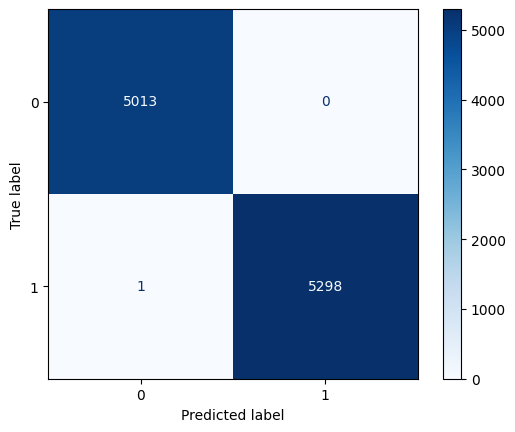

In [38]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
cm_display.plot(cmap='Blues')

<Axes: >

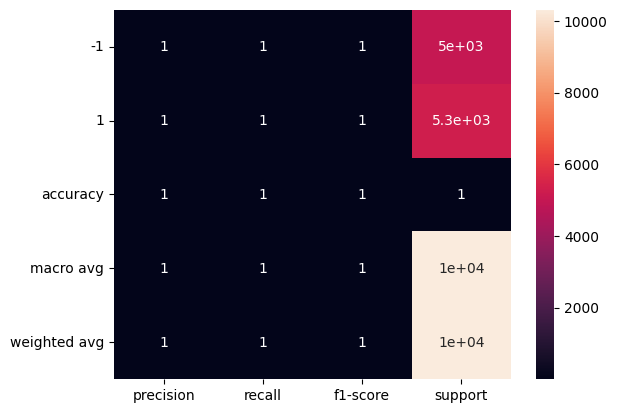

In [39]:
clf_report = classification_report(y_test, y_pred, output_dict = True)
sns.heatmap(pd.DataFrame(clf_report).T, annot=True)

In [40]:
print('Score', forest.score(X_test, y_test))
scores.append(forest.score(X_test, y_test))

Score 0.9999030256012412


##Comparing the Scores from Evaluation Techniques
Comparing model scores reveals which algorithm performs best in malware detection. Additional metrics such as precision and recall help in cases where false negatives are costly.

In [41]:
scores

[0.9983514352211016, 0.9999030256012412, 0.997187742435997, 0.9999030256012412]

#Conclusion
This notebook demonstrated a step-by-step approach to detecting malware using supervised learning models. Starting from data loading and preprocessing, several models were trained and evaluated. The project explored both simple (e.g., Decision Tree, Logistic Regression) and complex models (e.g., SVM, Random Forest) to determine which method best identifies malware.

Malware detection is critical in cybersecurity. This notebook equips learners with the tools to apply machine learning in cybersecurity by offering hands-on experience with classification models and model evaluation techniques. Understanding these methods enhances the capability to build robust systems that protect against malicious software threats.

## Interactive Model Score Comparison

Use the dropdown menu below to select a model and view its performance score. This allows for quick comparison of the models trained in this notebook.

In [42]:
import ipywidgets as widgets
from IPython.display import display

# Assuming the 'scores' list is in the order: Decision Tree, Logistic Regression, SVM, Random Forest
model_names = ['Decision Tree', 'Logistic Regression', 'SVM', 'Random Forest']
model_scores = dict(zip(model_names, scores))

def display_model_score(model_name):
    """Displays the score for the selected model."""
    if model_name in model_scores:
        print(f"The score for {model_name} is: {model_scores[model_name]:.4f}")
    else:
        print("Please select a valid model.")


In [44]:
# Create a dropdown widget
model_selector = widgets.Dropdown(
    options=model_names,
    description='Select Model:',
    disabled=False,
)

# Link the dropdown to the display function
widgets.interact(display_model_score, model_name=model_selector);

interactive(children=(Dropdown(description='Select Model:', options=('Decision Tree', 'Logistic Regression', '…

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [47]:
import joblib

joblib.dump(rf, "malware_model.pkl")  # replace rf with your best model

['malware_model.pkl']

In [49]:
!pip install gradio joblib -q

import gradio as gr
import pandas as pd
import joblib

# Load trained model
model = joblib.load("malware_model.pkl")

def predict_malware(file):
    try:
        data = pd.read_csv(file.name)

        # Remove label column if present
        if 'labels' in data.columns:
            data = data.drop(columns=['labels'])

        prediction = model.predict(data)

        malware_count = sum(prediction)
        safe_count = len(prediction) - malware_count

        if malware_count > 0:
            result = f"""
🚨 MALWARE ANALYSIS COMPLETE

📁 Total Files Checked: {len(prediction)}
⚠️ Malware Detected: {malware_count}
✅ Safe Files: {safe_count}

STATUS: THREAT DETECTED
"""
        else:
            result = f"""
🛡️ MALWARE ANALYSIS COMPLETE

📁 Total Files Checked: {len(prediction)}
⚠️ Malware Detected: 0
✅ Safe Files: {safe_count}

STATUS: ALL FILES SAFE
"""

        return result

    except Exception as e:
        return f"Error: {str(e)}"


custom_css = """
.gradio-container {
    max-width: 1000px !important;
}
h1 {
    text-align:center;
}
"""

with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
# 🛡️ AI Malware Detection System

### Machine Learning Based Cybersecurity Scanner

Upload a CSV file and instantly detect malicious software using your trained ML model.
""")

    with gr.Row():

        with gr.Column():
            file_input = gr.File(
                label="📂 Upload Malware Dataset",
                file_types=[".csv"]
            )

            predict_btn = gr.Button(
                "🔍 Scan For Malware",
                variant="primary"
            )

        with gr.Column():
            output = gr.Textbox(
                label="📊 Detection Report",
                lines=12
            )

    predict_btn.click(
        fn=predict_malware,
        inputs=file_input,
        outputs=output
    )

    gr.Markdown("""
---
### 🔐 Features

✅ Machine Learning Based Detection
✅ Real-Time Malware Classification
✅ CSV Upload Support
✅ Safe vs Malware Statistics
✅ Professional Cybersecurity Dashboard
""")

demo.launch(share=True)

/tmp/ipykernel_2355/4138470828.py:59: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
/tmp/ipykernel_2355/4138470828.py:59: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://be538b8c328703839f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [51]:
!pip install nbformat